In [49]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from bct.algorithms.clustering import clustering_coef_wu
from bct.algorithms.distance import charpath
from bct.utils.other import threshold_proportional, normalize
from itertools import combinations
from scipy.sparse.csgraph import shortest_path, laplacian
from scipy.linalg import eigh
from scipy.io import mmread, loadmat
from scipy.spatial.distance import cdist
from small_world_propensity import characteristic_path_length, clustering_coefficient_bct, SWP, make_lattice_null, make_random_null
import dill
from sklearn.preprocessing import MinMaxScaler

In [2]:
def characteristic_path_length(adj):
    """
    Calculates the characteristic path length, L. Since this is for weighted networks, 
    the distance between two nodes is defined as the inverse of the weight of the edge 
    connecting the nodes, hence, d_ij = 1/w_ij.
    This uses scipy.sparse.csgraph.shortest_path to find the shortest paths.

    Inputs
    ---
    adj : Weighted, undirected graph adjacency matrix.

    Returns
    ---
    L   : Characteristic path length for inputted network.
    
    """
    # All floats
    adj = adj.astype(float)
    # Ensure symmetric
    adj = (adj + adj.T) / 2
    """
    G = nx.Graph(adj)
    # Use only largest connected component (maybe not correct, but ideally all graphs will be connected)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G0 = G.subgraph(largest_cc)
        adj = nx.adjacency_matrix(G0).toarray()
    """
    # Number of nodes
    N = adj.shape[0]
    # Create distance matrix by replacing edge weights with d_ij = 1/w_ij
    with np.errstate(divide='ignore'):
        dist = np.where(adj != 0, 1.0 / adj, np.inf)
    np.fill_diagonal(dist, 0.0)
    dist = shortest_path(dist, method='auto', directed=False)
    
    L = dist.sum() / (N * (N - 1))

    return L

In [15]:
# Read in C. elegans and convert to adjacency matrix
elegans = pd.read_excel('NeuronConnect_C_elegans.xls')
elegans['weight'] = elegans['Nbr']
G = nx.from_pandas_edgelist(df=elegans, source='Neuron 1', target='Neuron 2', edge_attr='weight')
elegans_adj = nx.adjacency_matrix(G).toarray()

# Read in HCP SC and FC for one subject
sc = np.load('/home/gbz6qn/Documents/research/data/hcp_shen_sc/sub-100206_parc-shen268_tract-prob_sc.npy')
fc = np.load('/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/101309/symmetrized/covariance_symmetrized.npy')

In [122]:
print(sns.color_palette("Oranges").as_hex())

['#fee3c8', '#fdc692', '#fda057', '#f67824', '#e05206', '#ad3803']


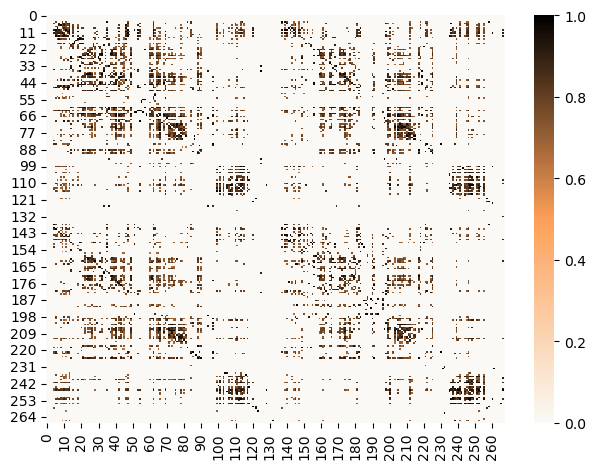

In [162]:
new = threshold_proportional(fc, 0.092)
scaled = MinMaxScaler().fit_transform(new)
fig, ax = plt.subplots()
sns.heatmap(scaled, cmap=sns.color_palette("blend:#FAF9F6,#fda057,#000000", as_cmap=True))
plt.tight_layout()
plt.savefig('example_fc_thresh_heatmap.png')
plt.show()

In [80]:
SWP(fc)

(np.float64(0.4839744749475202),
 np.float64(0.2380021060973579),
 np.float64(0.6898693227739561))

In [76]:
SWP(fc)

(np.float64(0.2928932188134524), np.float64(0.0), np.float64(1.0))

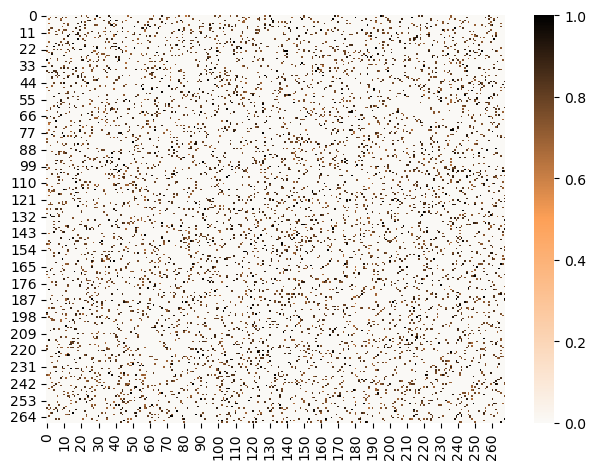

In [167]:
foo = fc.copy()
np.fill_diagonal(foo, np.nan)
#n = MinMaxScaler().fit_transform(foo)
t = threshold_proportional(new, p=0.1)
np.fill_diagonal(t, 0)
latt = make_lattice_null(new)
#scaled = MinMaxScaler().fit_transform(latt)
rand = make_random_null(new)
scaled = MinMaxScaler().fit_transform(rand)
np.fill_diagonal(scaled, 0)
fig, ax = plt.subplots()
sns.heatmap(scaled, cmap=sns.color_palette("blend:#FAF9F6,#fda057,#000000", as_cmap=True))
plt.tight_layout()
plt.savefig('example_fc_thresh_rand.png')
plt.show()

<Axes: >

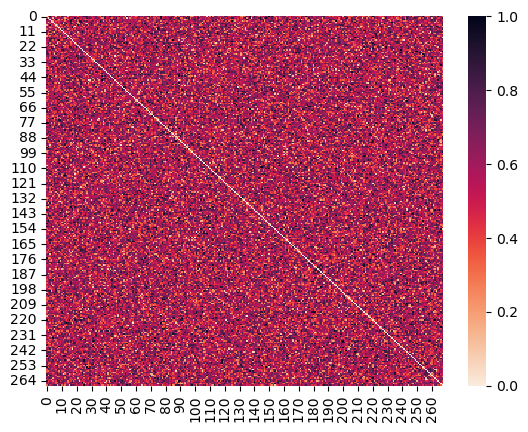

In [116]:
sns.heatmap(rand, cmap='rocket_r')

In [109]:
np.isnan(t).sum()

np.int64(268)

<Axes: >

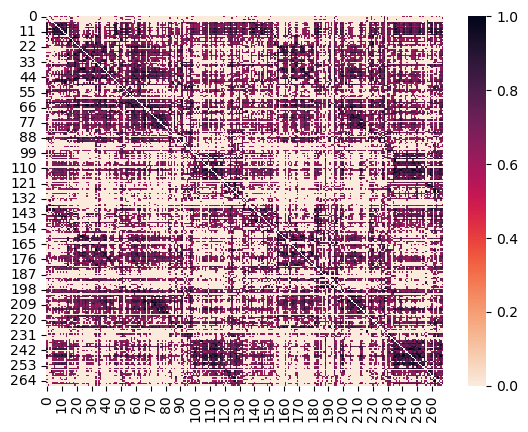

In [113]:
sns.heatmap(t, cmap='rocket_r')

In [92]:
fc.max()

np.float64(0.9351156)

In [93]:
fc.min()/fc.max()

np.float64(-0.37562928048681893)

<Axes: ylabel='Density'>

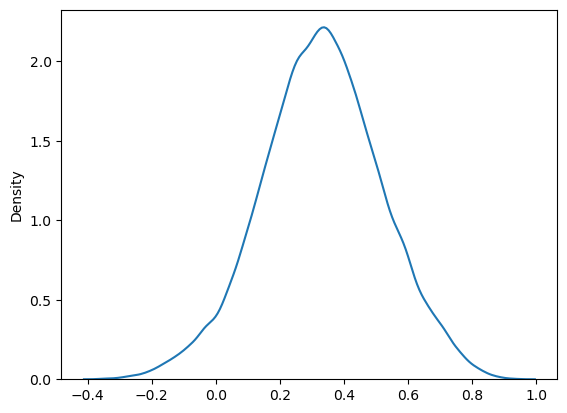

In [102]:
sns.kdeplot(foo.flatten())

<Axes: ylabel='Density'>

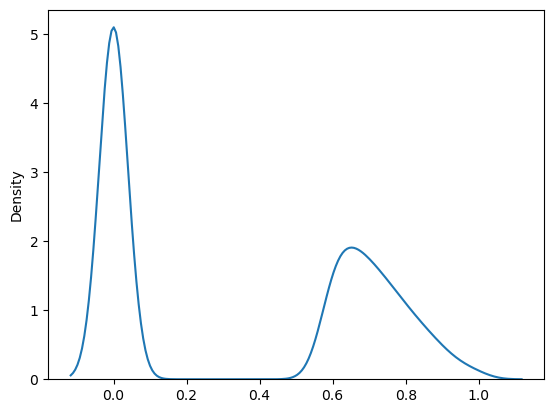

In [110]:
sns.kdeplot(t.flatten())

In [66]:
t = threshold_proportional(t, p=0.092)
N = len(t)
with np.errstate(divide='ignore'):
    dist = np.where(t > 0, 1.0 / t, np.inf)
np.fill_diagonal(dist, 0.0)
dist = shortest_path(dist, method='auto', directed=False)
dist = np.where(np.isinf(dist), 0, dist)
L = dist.sum() / (N * (N - 1))
print(L)

2.2413567827031318


<Axes: >

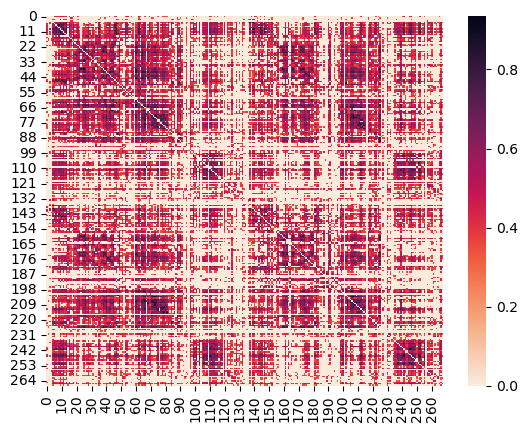

In [42]:
sns.heatmap(t, cmap='rocket_r')

In [60]:
np.nanmax(dist)

np.float64(9.039309975075945)

In [61]:
np.isinf(dist).sum()

np.int64(0)

<Axes: >

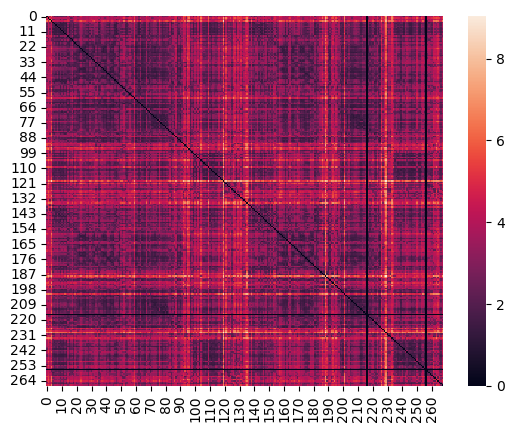

In [62]:
sns.heatmap(dist)

In [17]:
def clustering_coefficient_bct(adj):
    """
    Calculates the local clustering coefficient for each node using the method 
    from Onnela et al. and returns the average clustering coefficient across all nodes. 
    This uses clustering_coef_wu() from bctpy because it is faster than my implementation, 
    but it does not normalize by the max weight, so this is done manually. The bctpy 
    implementation also is not averaged, but returns all local clustering coefficients, so
    this averages the returned local coefficients.

    Inputs
    ---
    adj : Weighted, undirected adjacency matrix of the observed network.

    Returns
    ---
    C   : Global clustering coefficient.
    """
    adj = adj.astype(float)
    adj = (adj + adj.T) / 2
    G = nx.Graph(adj)
    # Use only largest connected component (maybe not correct, but ideally all graphs will be connected)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G0 = G.subgraph(largest_cc)
        adj = nx.adjacency_matrix(G0).toarray()
    # BCT doesn't normalize by w_max, but it's a faster implementation, so manually calculate w_max
    w_max = adj[~np.eye(adj.shape[0], dtype=bool)].max()
    if w_max == 0:
        return 0.0
    # Use BCT and normalize manually
    C = np.mean(clustering_coef_wu(adj / w_max))
    return C

In [20]:
def clustering_coefficient_bct2(adj):
    """
    Calculates the local clustering coefficient for each node using the method 
    from Onnela et al. and returns the average clustering coefficient across all nodes. 
    This uses clustering_coef_wu() from bctpy because it is faster than my implementation, 
    but it does not normalize by the max weight, so this is done manually. The bctpy 
    implementation also is not averaged, but returns all local clustering coefficients, so
    this averages the returned local coefficients.

    Inputs
    ---
    adj : Weighted, undirected adjacency matrix of the observed network.

    Returns
    ---
    C   : Global clustering coefficient.
    """
    adj = adj.astype(float)
    adj = (adj + adj.T) / 2
    
    # BCT doesn't normalize by w_max, but it's a faster implementation, so manually calculate w_max
    w_max = adj[~np.eye(adj.shape[0], dtype=bool)].max()
    if w_max == 0:
        return 0.0
    # Use BCT and normalize manually
    C = np.mean(clustering_coef_wu(adj / w_max))
    return C

In [15]:
spi_dir = '/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/'
sc_dir = '/home/gbz6qn/Documents/research/data/hcp_shen_sc/'
subs = os.listdir(spi_dir)

In [53]:
c_abs = []
c_orig = []
l_abs = []
l_orig = []

for i, sub in tqdm(enumerate(subs)):
    sub_path = os.path.join(spi_dir, sub, 'symmetrized', 'covariance_symmetrized.npy')
    fc = np.load(sub_path)
    fc_abs = np.abs(fc)

    c_o = clustering_coefficient_bct(fc)
    c_orig.append(c_o)
    c_a = clustering_coefficient_bct(fc_abs)
    c_abs.append(c_a)

    l_o = characteristic_path_length(fc)
    if np.isinf(l_o):
        print(f'Sub {sub} has infinite path length.')
        continue
    l_orig.append(l_o)
    l_a = characteristic_path_length(fc_abs)
    l_abs.append(l_a)

174it [01:10,  2.85it/s]

Sub 529549 has infinite path length.


338it [02:15,  2.50it/s]


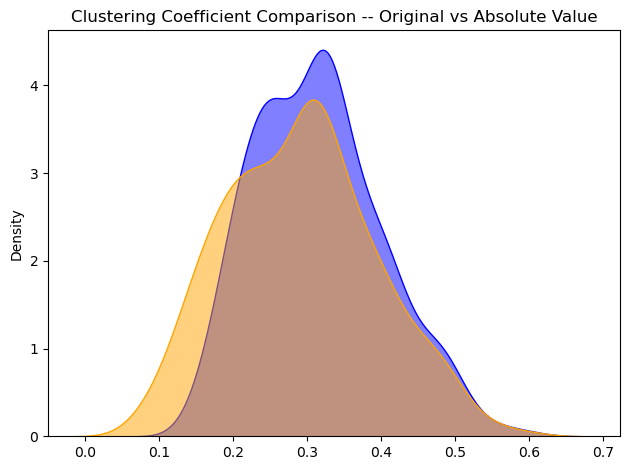

In [59]:
fig, ax = plt.subplots()
sns.kdeplot(c_abs, color='blue', alpha=0.5, fill=True)
sns.kdeplot(c_orig, color='orange', alpha=0.5, fill=True)
plt.title('Clustering Coefficient Comparison -- Original vs Absolute Value')
plt.tight_layout()
plt.show()

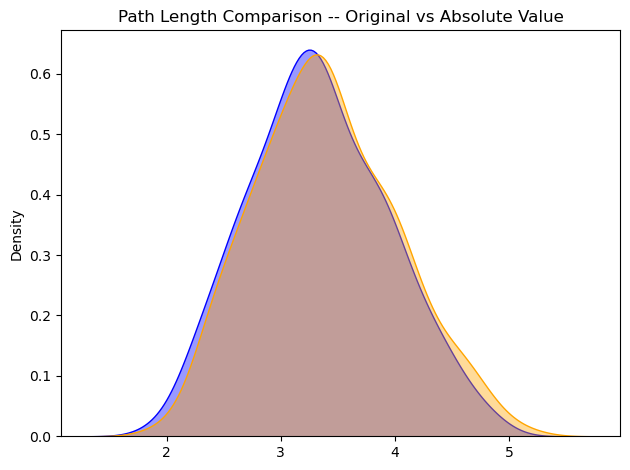

In [56]:
fig, ax = plt.subplots()
sns.kdeplot(l_abs, color='blue', alpha=0.4, fill=True)
sns.kdeplot(l_orig, color='orange', alpha=0.4, fill=True)
plt.title('Path Length Comparison -- Original vs Absolute Value')
plt.tight_layout()
plt.show()

In [54]:
foo = np.array(l_orig) - np.array(l_abs)

In [66]:
swp_orig = []
dC_orig = []
dL_orig = []
swp_abs = []
dC_abs = []
dL_abs = []
failures_orig = []
failures_abs = []
for i, sub in tqdm(enumerate(subs)):
    sub_path = os.path.join(spi_dir, sub, 'symmetrized', 'covariance_symmetrized.npy')
    fc = np.load(sub_path)
    fc_abs = np.abs(fc)

    swp_o, dc_o, dl_o = SWP(fc)
    if np.isfinite(swp_o) and np.isfinite(dc_o) and np.isfinite(dl_o):
        swp_orig.append(swp_o)
        dC_orig.append(dc_o)
        dL_orig.append(dl_o)
    else:
        failures_orig.append(sub)

    swp_a, dc_a, dl_a = SWP(fc_abs)
    if np.isfinite(swp_a) and np.isfinite(dc_a) and np.isfinite(dl_a):
        swp_abs.append(swp_a)
        dC_abs.append(dc_a)
        dL_abs.append(dl_a)
    else:
        failures_abs.append(sub)

338it [11:43,  2.08s/it]


In [68]:
len(failures_abs)

0

In [69]:
results_orig = {'swp': swp_orig, 'delta_C': dC_orig, 'delta_L': dL_orig}
results_abs = {'swp': swp_abs, 'delta_C': dC_abs, 'delta_L': dL_abs}

In [71]:
results_combo = {'original': results_orig, 'absolute': results_abs}

In [74]:
with open('results_original_abs.dill', 'wb') as f:
    dill.dump(results_combo, f)

In [2]:
with open('results_original_abs.dill', 'rb') as f:
    results = dill.load(f)

In [4]:
original = results['original']
absolute = results['absolute']

In [5]:
original.keys()

dict_keys(['swp', 'delta_C', 'delta_L'])

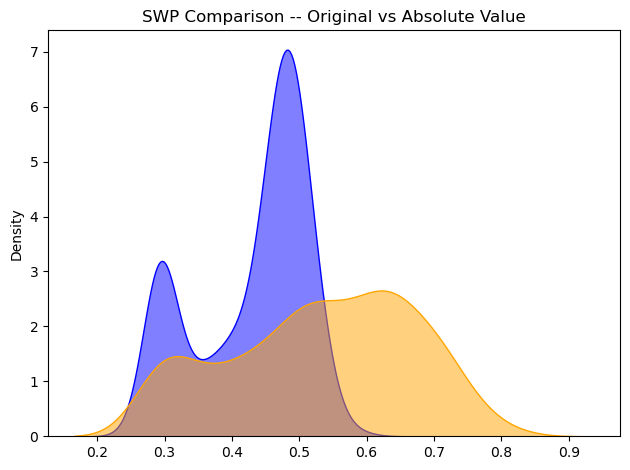

In [6]:
fig, ax = plt.subplots()
sns.kdeplot(original['swp'], color='blue', alpha=0.5, fill=True)
sns.kdeplot(absolute['swp'], color='orange', alpha=0.5, fill=True)
plt.title('SWP Comparison -- Original vs Absolute Value')
plt.tight_layout()
plt.show()

/tmp/ipykernel_419730/4287902573.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(absolute['delta_C'], color='orange', alpha=0.5, fill=True)


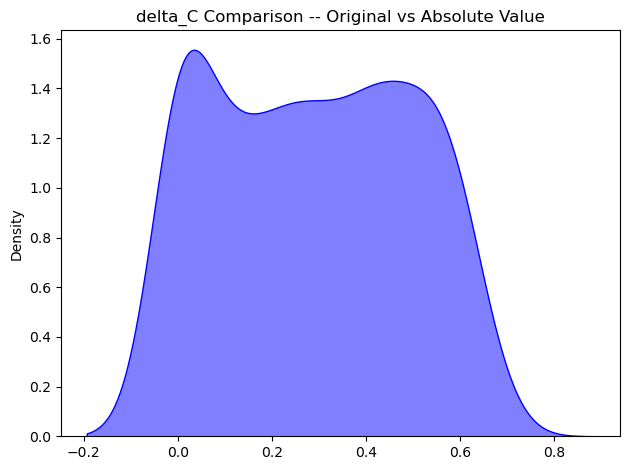

In [11]:
fig, ax = plt.subplots()
sns.kdeplot(original['delta_C'], color='blue', alpha=0.5, fill=True)
sns.kdeplot(absolute['delta_C'], color='orange', alpha=0.5, fill=True)
plt.title('delta_C Comparison -- Original vs Absolute Value')
plt.tight_layout()
plt.show()

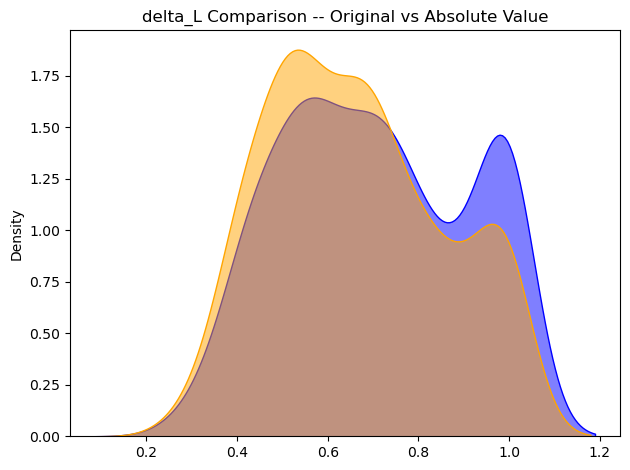

In [10]:
fig, ax = plt.subplots()
sns.kdeplot(original['delta_L'], color='blue', alpha=0.5, fill=True)
sns.kdeplot(absolute['delta_L'], color='orange', alpha=0.5, fill=True)
plt.title('delta_L Comparison -- Original vs Absolute Value')
plt.tight_layout()
plt.show()

In [18]:
def threshold_by_density(adj, density):
    """
    Thresholds an adjacency matrix by a given density.

    Inputs
    ---
    adj     : Weighted, undirected adjacency matrix of the observed network.

    density : Target density [0.0, 1.0].

    Returns
    ---
    thresholded      :   Density thresholded matrix.

    actual_density   :   Final density of the thresholded matrix.

    threshold_value  :   Edge weight threshold used.
    
    """

    n = len(adj)
    upper_tri_indices = np.triu_indices(n, k=1)
    upper_tri_weights = adj[upper_tri_indices]

    # Determine number of connections to keep
    n_possible = len(upper_tri_weights)
    n_to_keep = int(np.ceil(density * n_possible))

    # Sort weights in descending order
    sorted_weights = np.sort(upper_tri_weights)[::-1]
    if n_to_keep < len(sorted_weights):
        threshold_value = sorted_weights[n_to_keep - 1]
    else:
        threshold_value = sorted_weights[-1] - 1

    # Create new thresholded matrix
    thresholded = np.zeros_like(adj)
    thresholded = np.where(adj >= threshold_value, adj, 0)
    np.fill_diagonal(thresholded, 0)

    # Calculate actual final density
    upper_tri_kept = thresholded[upper_tri_indices]
    actual_density = np.sum(upper_tri_kept > 0) / n_possible

    return thresholded, actual_density, threshold_value

In [21]:
t, den, val = threshold_by_density(fc, 0.9)
print(f'Density: {den}, threshold value: {val}')

Density: 0.9000223601095645, threshold value: 0.09301395


<Axes: >

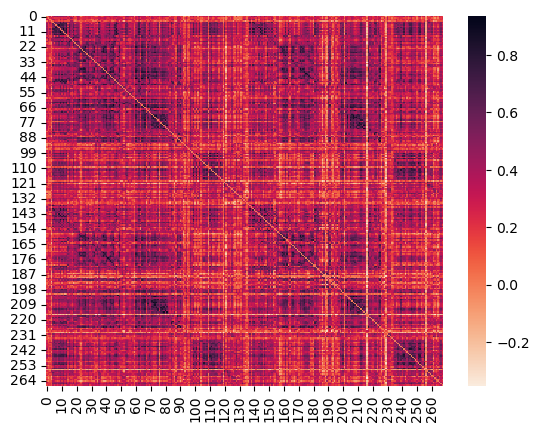

In [23]:
sns.heatmap(fc, cmap='rocket_r')

In [8]:
G = nx.Graph(t)
largest_cc = max(nx.connected_components(G), key=len)
G0 = G.subgraph(largest_cc)
adj = nx.adjacency_matrix(G0).toarray()
adj.shape

(236, 236)

In [132]:
SWP(t)

Graph is not fully connected.


(np.float64(0.7111416304319459),
 np.float64(0.38471304906231074),
 np.float64(0.13738335132107232))

In [4]:
G = nx.Graph(fc)
max_tree = nx.adjacency_matrix(nx.maximum_spanning_tree(G)).toarray()
min_tree = nx.adjacency_matrix(nx.minimum_spanning_tree(G)).toarray()

<Axes: >

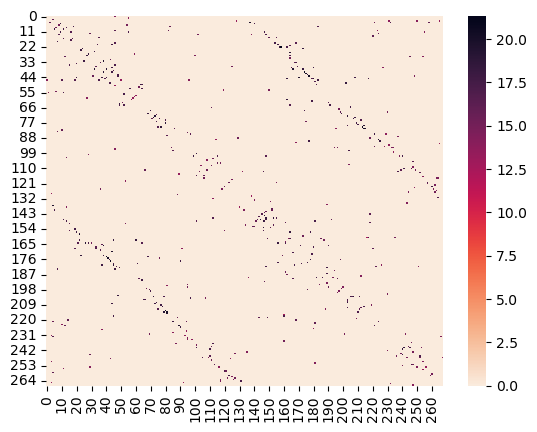

In [5]:
sns.heatmap(max_tree, cmap='rocket_r')

<Axes: >

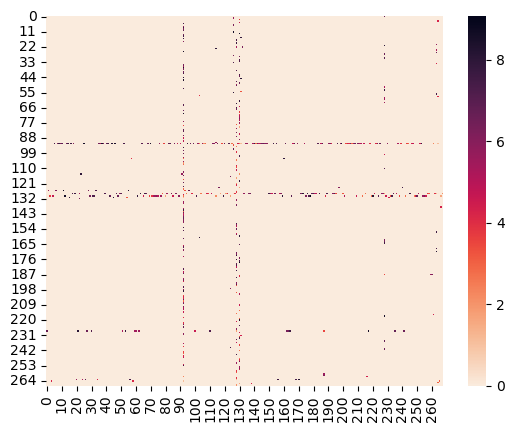

In [6]:
sns.heatmap(min_tree, cmap='rocket_r')

In [12]:
upper_tri = np.triu(max_tree, k=1)
n = len(min_tree)
E = np.count_nonzero(upper_tri)
r = int(np.ceil(E / n))

In [14]:
r

1

In [67]:
E

14312

In [12]:
[len(c) for c in sorted(nx.connected_components(nx.Graph(t)), key=len, reverse=True)]

[214,
 3,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [24]:
vals = []
for sub in subs:
    sub_path = os.path.join(spi_dir, sub, 'symmetrized', 'phase_slope_wavelet_symmetrized.npy')
    fc_raw = np.load(sub_path)
    fc = np.where(fc_raw > 0, fc_raw, 0)
    mean_val = np.mean(fc)
    vals.append(mean_val)
mean = np.mean(vals)
sd = np.std(vals)
print(f'mean={mean:.3f}, sd={sd:.3f}')

mean=0.168, sd=0.041


<Axes: ylabel='Density'>

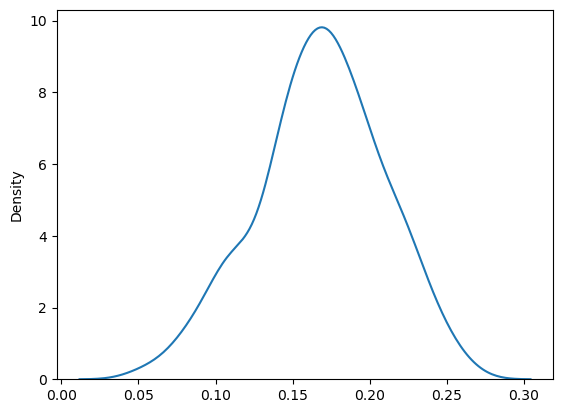

In [25]:
sns.kdeplot(vals)

In [41]:
adj = np.where(fc > 0.2, fc, 0)
# Number of nodes
N = adj.shape[0]
# Create distance matrix by replacing edge weights with d_ij = 1/w_ij
with np.errstate(divide='ignore'):
    dist = np.where(adj != 0, 1.0 / adj, np.inf)
np.fill_diagonal(dist, 0.0)
paths = shortest_path(dist, method='auto', directed=False)
paths = np.where(np.isinf(paths), 0, paths)

L = paths.sum() / (N * (N - 1))
L2 = np.mean(paths)

In [32]:
nx.is_connected(nx.Graph(adj))

False

In [35]:
L

np.float64(3.118917302459946)

In [36]:
L2

np.float64(3.1072795513313642)

In [24]:
with np.errstate(divide='ignore'):
    dist = np.where(adj != 0, 1.0 / adj, np.inf)

In [37]:
np.isinf(paths).sum()

np.int64(0)

In [43]:
def consensus_threshold(matrices, rho, x_pct) -> np.ndarray:
    """
    Consensus thresholding on a stack of adjacency matrices.

    Parameters
    ----------
    matrices : np.ndarray, shape (n_subjects, n_nodes, n_nodes)
        Stack of weighted adjacency matrices with edge weights in [0, 1].
    rho : float
        Minimum edge weight to count as "present" in a subject.
    x_pct : float
        Minimum fraction of subjects (in [0, 1]) that must have the edge
        above rho for it to be retained. E.g. 0.5 = 50%.

    Returns
    -------
    consensus_mask : np.ndarray, shape (n_nodes, n_nodes)
        Binary consensus mask (1 = retained, 0 = eliminated).
    mean_matrix_threshold : np.ndarray, shape (n_nodes, n_nodes)
        Mean weight matrix masked by consensus (useful as a weighted output).
    """
    n_subjects = matrices.shape[0]

    # Step 1: binarize each subject's matrix at threshold rho
    # (n_subjects, n_nodes, n_nodes)
    present = (matrices >= rho)

    # Step 2: fraction of subjects with edge above rho
    prevalence = present.mean(axis=0)

    # Step 3: retain edges meeting the consensus criterion
    consensus_mask = (prevalence >= x_pct)

    # Step 4: apply mask to mean weights (common output format)
    mean_matrix = matrices.mean(axis=0)
    mean_matrix_thresholded = mean_matrix * consensus_mask

    return consensus_mask, mean_matrix_thresholded

In [44]:
spi_dir = '/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/'
sc_dir = '/home/gbz6qn/Documents/research/data/hcp_shen_sc/'
# List of subs
with open('/home/gbz6qn/Documents/research/code/coupling/compute_gca/subs.txt', 'r') as f:
    lines = f.read()
    subs = lines.split('\n')[:-1]
subs = sorted(subs)
# Load in all subjects into stacked array
all_subs = []
for sub in subs:
    fc_path = os.path.join(spi_dir, sub, 'symmetrized', 'covariance_symmetrized.npy')
    fc_raw = np.load(fc_path)
    fc = np.abs(fc_raw)
    all_subs.append(fc)
stacked = np.stack(all_subs)

In [47]:
_, t = consensus_threshold(stacked, 0.3, 0.5)

In [48]:
SWP(t)

(np.float64(0.6924505973232342),
 np.float64(0.0),
 np.float64(0.43494053636522645))

In [57]:
adj = np.where(fc > 0.2, fc, 0)
# Number of nodes
N = adj.shape[0]
# Create distance matrix by replacing edge weights with d_ij = 1/w_ij
with np.errstate(divide='ignore'):
    dist = np.where(adj != 0, 1.0 / adj, np.inf)
np.fill_diagonal(dist, 0.0)
d, _, _, _, _ = charpath(dist, include_infinite=False)
d

np.float64(2.651017030799237)

In [58]:
characteristic_path_length(adj)

np.float64(2.872378290177941)